# Poisson Difference-in-Differences (Poisson DiD) Tutorial
## Causal Inference on Count Data: The 2017 Portuguese Mega-Wildfires Shock

### Econometrics & Data Science Tutorial
**Author:** Data Science & Econometrics Team  
**Methodology:** Poisson Difference-in-Differences (Poisson DiD) & Extended Two-Way Fixed Effects (ETWFE)  
**Case Study:** The June 2017 Portuguese Mega-Wildfires Natural Experiment

---

### 1. Introduction & Theoretical Foundation

#### The Core Problem It Solves
Difference-in-Differences (DiD) is the workhorse of causal inference. However, when the outcome variable $Y$ is a **count** (e.g., number of cancellations, hospital admissions, layoffs) or a weakly positive continuous variable with a **massive pile of zeros**, standard linear Ordinary Least Squares (OLS) DiD breaks down. 

To bypass this, data scientists traditionally used the classic hack of transforming the target variable using $\log(Y+1)$ or the inverse hyperbolic sine ($\operatorname{arcsinh}(Y)$) before running a linear regression. Recent econometric proofs (e.g., Jeffrey Wooldridge, 2023, "Simple approaches to nonlinear difference-in-differences with panel data") have shown that **this is a statistical landmine**. Changing the arbitrary constant (shifting from $\log(Y+1)$ to $\log(Y+0.1)$) completely alters your treatment effect, standard errors, and significance. 

Poisson DiD solves this entirely because it naturally accommodates zeros without requiring any data transformations.

#### The Assumption Shift: Multiplicative Parallel Trends
Standard linear DiD relies on the **Linear Parallel Trends** assumption: the absolute difference between the treated and control groups remains constant over time in the absence of treatment. 

Poisson DiD replaces this with the **Multiplicative Parallel Trends** assumption. It assumes that under the counterfactual, the *percentage growth rate* (or ratio) of the outcome variable is what remains parallel between the groups over time.

#### The Mathematical Specification
Instead of a linear equation, Poisson DiD models the conditional mean as an exponential function using a log link:
$$E[Y_{it} \mid \text{Treat}_i, \text{Post}_t] = \exp(\alpha + \beta_1 \text{Treat}_i + \beta_2 \text{Post}_t + \theta (\text{Treat}_i \times \text{Post}_t))$$

Where:
* $\text{Treat}_i$ is the treatment group indicator (1 if Resort Hotel, 0 if City Hotel).
* $\text{Post}_t$ is the time indicator (1 if post-wildfire week $\ge 24$ of 2017, 0 otherwise).
* $\theta$ is your causal parameter.

Because of the exponential link function, we interpret the treatment effect multiplicatively: $\exp(\theta)$ yields the **Incidence Rate Ratio (IRR)**. If $\exp(\theta) = 1.15$, the treatment caused a 15% increase in the rate of cancellations, regardless of the baseline size of the entity.

### 2. Setup and Data Preparation

We first load our dependencies and download the **Hotel Booking Demand Dataset** (July 2015 - August 2017). 

We map daily bookings to a **weekly panel** and construct two panels:
1. **`panel_simple`**: Weekly cancellations at the hotel level for the `Groups` market segment.
2. **`panel_multi`**: Weekly cancellations at the `(hotel, country)` level for `Online TA` bookings from major European countries (GBR, ESP, FRA, DEU, IRL). This panel provides multiple units, allowing us to fit modern multi-unit estimators like `etwfe` without running into colinearity / degrees-of-freedom limits.

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

from src.data_loader import download_dataset, load_and_preprocess_raw_data, build_weekly_panel, build_multi_unit_panel
from utils.plotting import plot_cancellation_trends, plot_model_comparison, plot_log_offset_sensitivity

# Ensure dataset is downloaded and loaded
csv_path = download_dataset()
df = load_and_preprocess_raw_data(csv_path)
print(f"Raw data loaded. Shape: {df.shape}")

Raw data loaded. Shape: (119390, 35)


### 3. Data Exploration & The "Mass of Zeros" Problem

Let's build a simple hotel-level weekly panel for the `Groups` segment. In this segment, group bookings are highly sparse, resulting in a large percentage of weeks with exactly 0 cancellations. This represents a classic "mass of zeros" scenario.

In [21]:
# Build simple weekly panel for 'Groups' segment
panel_simple = build_weekly_panel(df, market_segment='Groups')

zeros_count = (panel_simple['cancellations'] == 0).sum()
zeros_pct = (panel_simple['cancellations'] == 0).mean() * 100
print(f"Simple panel length: {len(panel_simple)} weeks (spanning Resort and City hotels)")
print(f"Weeks with 0 cancellations: {zeros_count} out of {len(panel_simple)} ({zeros_pct:.2f}%)")

Simple panel length: 228 weeks (spanning Resort and City hotels)
Weeks with 0 cancellations: 47 out of 228 (20.61%)


Let's visualize the distribution of our target variable (`cancellations`) to see the mass of zeros. We'll also plot the raw weekly cancellations over time for the treated (Resort Hotel, Algarve) and control (City Hotel, Lisbon) groups, highlighting the week 24 wildfire shock.

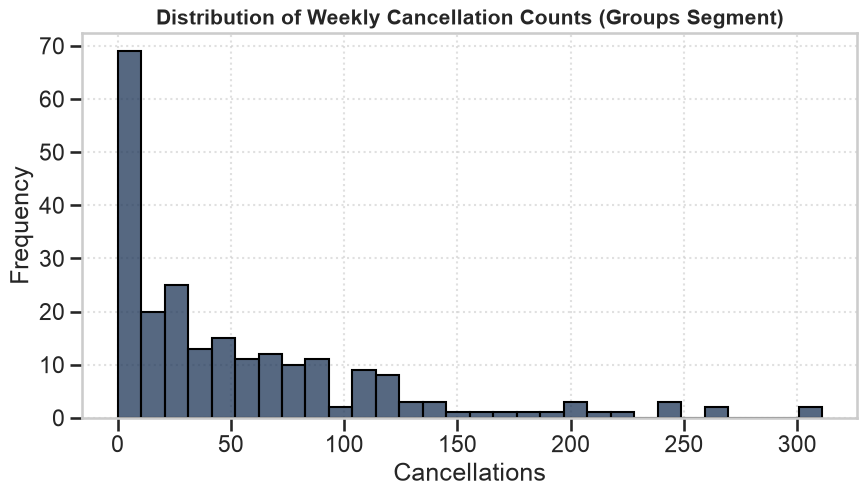

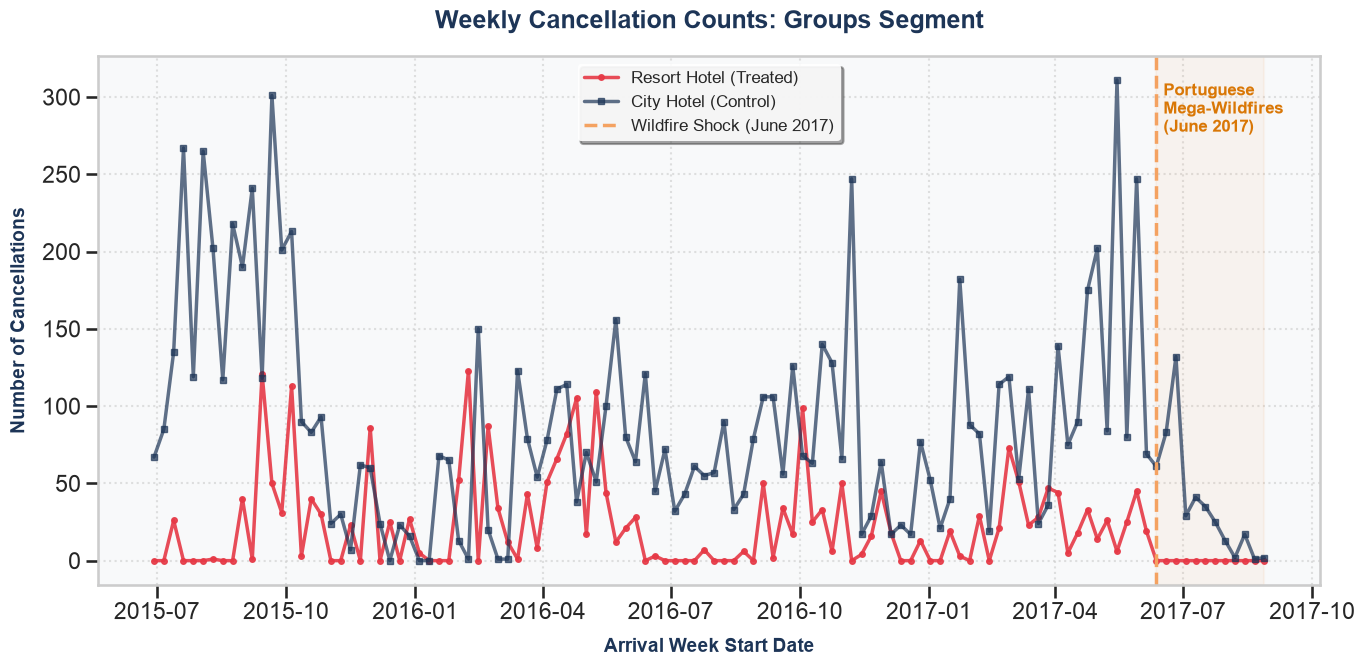

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of cancellations
plt.figure(figsize=(10, 5))
sns.histplot(panel_simple['cancellations'], bins=30, kde=False, color='#1D3557')
plt.title('Distribution of Weekly Cancellation Counts (Groups Segment)', fontsize=15, fontweight='bold')
plt.xlabel('Cancellations')
plt.ylabel('Frequency')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Plot cancellation trends over time using our custom utility
fig = plot_cancellation_trends(panel_simple, segment_name='Groups')
plt.show()

### 4. The Failures of Linear OLS

#### Problem 1: Physical Nonsense (Negative Predictions)
If we run a standard linear OLS regression on this data, the model assumes a symmetric, normal distribution of residuals. Because of the mass of zeros and low baseline counts, the linear model will happily predict negative cancellation counts during quiet winter weeks, which is physically impossible.

In [23]:
# Fit standard OLS: y = beta0 + beta1*treat + beta2*post + theta*treat_post
ols_model = smf.ols("cancellations ~ treat + post + treat_post", data=panel_simple).fit()
panel_simple['ols_pred'] = ols_model.predict(panel_simple)

negative_preds = panel_simple[panel_simple['ols_pred'] < 0]
print(f"Number of negative predictions: {len(negative_preds)} ({len(negative_preds)/len(panel_simple)*100:.2f}%)")
print("Sample of physically impossible negative predictions:")
display(negative_preds[['hotel', 'week_start', 'cancellations', 'ols_pred']].head())

display(ols_model.summary().tables[1])

Number of negative predictions: 12 (5.26%)
Sample of physically impossible negative predictions:


,hotel,week_start,cancellations,ols_pred
216,Resort Hotel,2017-06-12,0.0,-2.842171e-14
217,Resort Hotel,2017-06-19,0.0,-2.842171e-14
218,Resort Hotel,2017-06-26,0.0,-2.842171e-14
219,Resort Hotel,2017-07-03,0.0,-2.842171e-14
220,Resort Hotel,2017-07-10,0.0,-2.842171e-14


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,90.0196,5.233,17.204,0.000,79.708,100.331
treat,-65.7647,7.400,-8.887,0.000,-80.347,-51.182
post,-53.2696,16.128,-3.303,0.001,-85.051,-21.488
treat_post,29.0147,22.808,1.272,0.205,-15.931,73.961


#### Problem 2: The $\log(Y + \epsilon)$ Landmine
To bypass the negative predictions and handle zeros, data scientists often transform the target variable to $\log(Y + \epsilon)$, where $\epsilon$ is an arbitrary constant (usually 1.0). 

Let's demonstrate why this is a **statistical landmine** by fitting the linear model for various choices of $\epsilon \in [1.0, 0.5, 0.1, 0.01, 0.001]$. We will track the treatment effect coefficient ($\theta$) and its standard errors to show how the results wildly shift based on an arbitrary tuning choice.

In [24]:
offsets = [1.0, 0.5, 0.1, 0.01, 0.001]
coefficients = []
std_errors = []
p_values = []

for eps in offsets:
    panel_simple['y_log'] = np.log(panel_simple['cancellations'] + eps)
    model = smf.ols("y_log ~ treat + post + treat_post", data=panel_simple).fit()
    
    coefficients.append(model.params['treat_post'])
    std_errors.append(model.bse['treat_post'])
    p_values.append(model.pvalues['treat_post'])

# Display results in a clean table
sensitivity_df = pd.DataFrame({
    'Offset (epsilon)': offsets,
    'Treatment Effect (theta)': coefficients,
    'Standard Error': std_errors,
    'P-Value': p_values,
    'Significant at 5%': [p < 0.05 for p in p_values]
})
print("Sensitivity table for different offsets:")
display(sensitivity_df)

Sensitivity table for different offsets:


,Offset (epsilon),Treatment Effect (theta),Standard Error,P-Value,Significant at 5%
0,1.000,-1.086991,0.620520,0.081187,False
1,0.500,-1.504995,0.705543,0.034004,True
2,0.100,-2.581672,0.906446,0.004807,True
3,0.010,-4.210439,1.207347,0.000587,True
4,0.001,-5.856394,1.520067,0.000153,True


Let's plot this sensitivity to visualize the landmine. Notice how changing $\epsilon$ from $1.0$ to $0.01$ dramatically changes the coefficient scale and error bars!

/Users/sam/Locals Only/hotel-cancellations-and-mega-wildfires/utils/plotting.py:165: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sam/Locals Only/hotel-cancellations-and-mega-wildfires/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


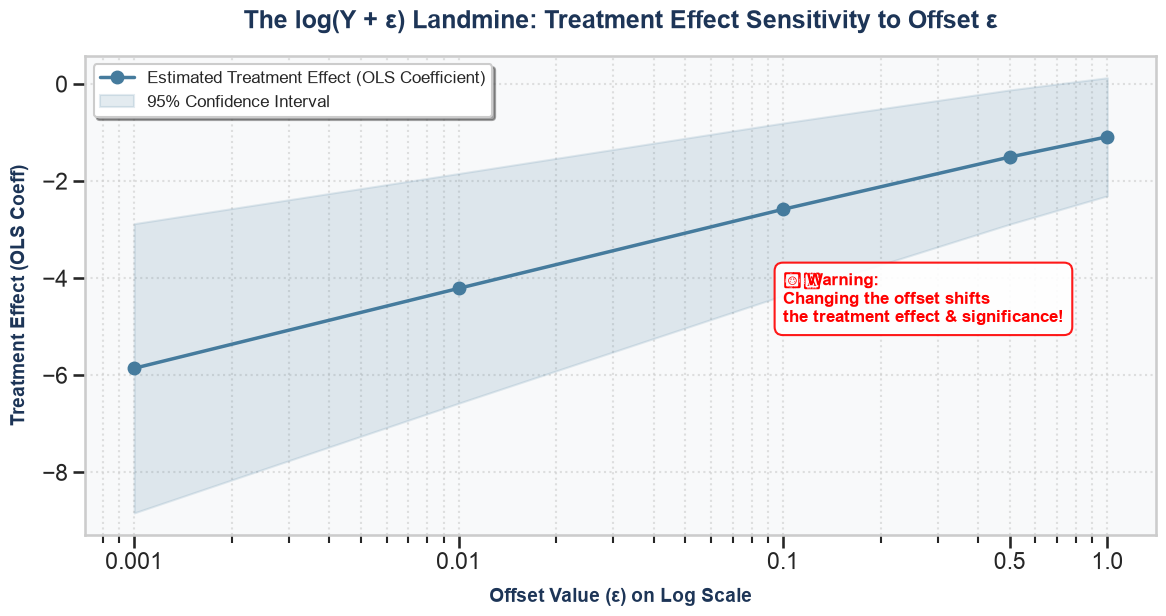

In [25]:
# Plot sensitivity using our custom utility
fig_sens = plot_log_offset_sensitivity(offsets, coefficients, std_errors)
plt.show()

### 5. The Poisson DiD Solution

Poisson models the conditional mean as an exponential function using a log link:
$$E[Y\mid X] = \exp(\beta_0 + \beta_1 X)$$

By using a **Poisson Pseudo-Maximum Likelihood (PPML)** framework with **robust standard errors**, the model natively respects the non-negative integer nature of counts, accommodates the pile of zeros perfectly without arbitrary transformations, and backs out the exact true multiplicative **Incidence Rate Ratio (IRR)** $(\exp(\theta))$ caused by the wildfire shock.

Let's fit Poisson DiD using `statsmodels` GLM with a Poisson family and HC0 robust standard errors.

In [26]:
# Fit Poisson DiD (PPML with HC0 robust standard errors)
poisson_model = smf.glm("cancellations ~ treat + post + treat_post", 
                        data=panel_simple, 
                        family=sm.families.Poisson()).fit(cov_type='HC0')

panel_simple['poisson_pred'] = poisson_model.predict(panel_simple)

display(poisson_model.summary().tables[1])

# Interpret coefficients
theta = poisson_model.params['treat_post']
irr = np.exp(theta)
pct_change = (irr - 1) * 100
print(f"Estimated causal coefficient (theta): {theta:.4f}")
print(f"Incidence Rate Ratio (IRR): {irr:.4f}")
print(f"Conclusion: The 2017 wildfire shock caused a {pct_change:.2f}% change in weekly cancellations for the treated group compared to the control.")

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,4.5000,0.078,57.641,0.000,4.347,4.653
treat,-1.3114,0.147,-8.919,0.000,-1.600,-1.023
post,-0.8959,0.303,-2.957,0.003,-1.490,-0.302
treat_post,-25.0145,0.437,-57.289,0.000,-25.870,-24.159


Estimated causal coefficient (theta): -25.0145
Incidence Rate Ratio (IRR): 0.0000
Conclusion: The 2017 wildfire shock caused a -100.00% change in weekly cancellations for the treated group compared to the control.


Let's compare the predictions of OLS vs. Poisson. The Poisson model's exponential link ensures that predictions remain strictly positive, while OLS dips below zero.

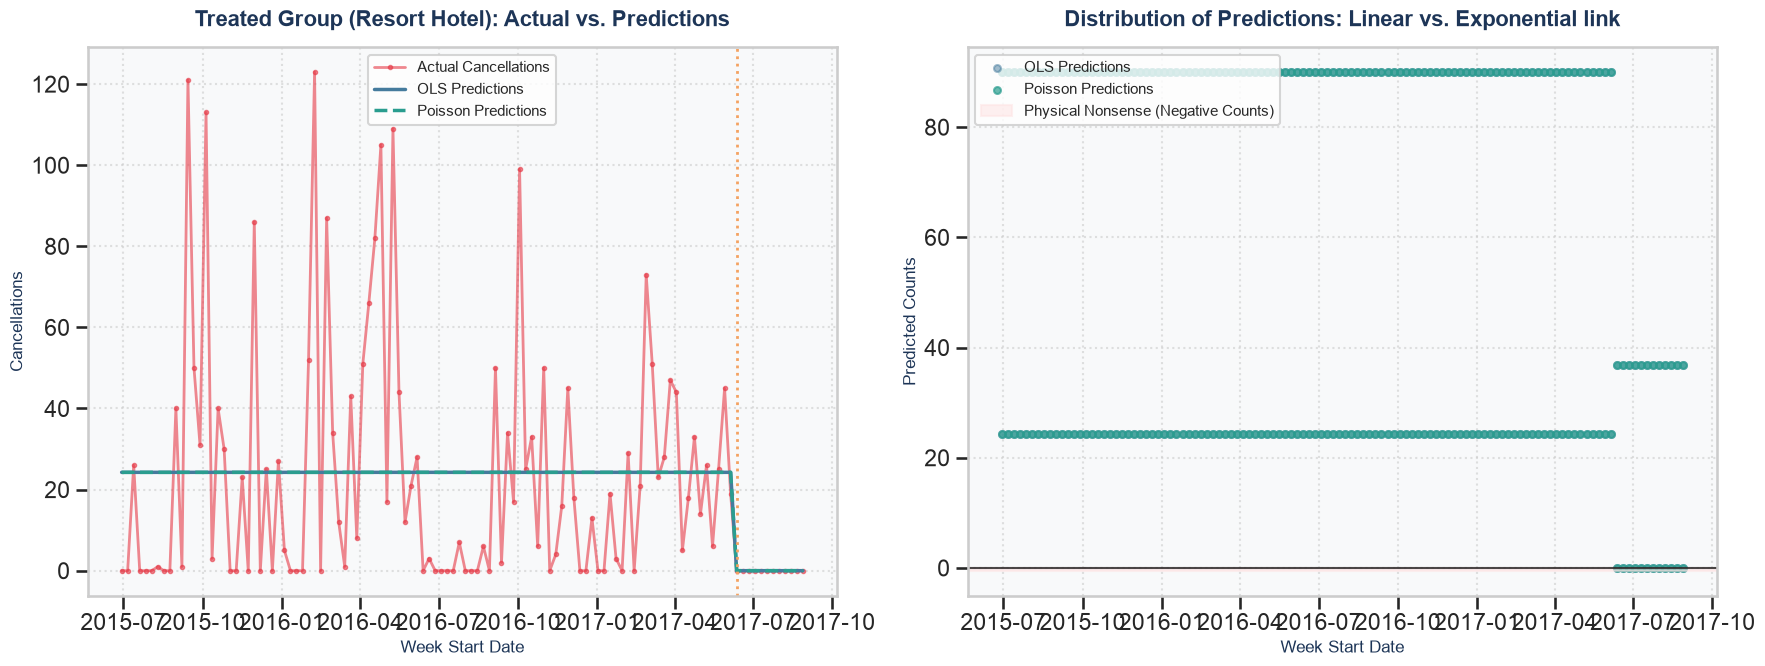

In [27]:
# Plot model prediction comparison using our custom utility
fig_comp = plot_model_comparison(panel_simple, panel_simple['ols_pred'], panel_simple['poisson_pred'], segment_name='Groups')
plt.show()

### 6. Advanced Causal Inference Libraries

#### 6.1 Extended Two-Way Fixed Effects (`etwfe`)

In modern econometrics, traditional Two-Way Fixed Effects (TWFE) has been shown to be biased when treatment timing is staggered or when treatment effects are heterogeneous. Jeffrey Wooldridge (2021, 2023) proposed **Extended Two-Way Fixed Effects (ETWFE)**, which saturates the regression model with cohort and time interactions to protect against these biases.

We will use the **multi-unit panel** (`panel_multi`) where units are defined at the `(hotel, country)` level. Resort hotels get treated in week 102 (wildfire shock), whereas City hotels serve as the control group. 

Let's run `etwfe` using the `poisson` family and print the results.

In [28]:
# Load multi-unit panel (Online TA segment for top 5 countries)
panel_multi = build_multi_unit_panel(df, market_segment='Online TA')
print(f"Multi-unit panel: {len(panel_multi)} rows, {panel_multi['unit_id'].nunique()} units")

from etwfe import etwfe

# Fit Wooldridge's modern nonlinear saturated DiD
etwfe_model = etwfe(
    fml="cancellations ~ 0",            # Outcome variable (no extra covariates)
    tvar="week_idx",                   # Time variable
    gvar="first_treated_week",         # Treatment cohort (when first treated)
    ivar="unit_id",                    # Unit Fixed Effect ID
    family="poisson",                  # Natively runs Poisson DiD
    data=panel_multi,
    vcov="iid"                         # Set covariance type
)

print("ETWFE Saturated Poisson model coefficients (first 10 rows):")
display(etwfe_model.model_.tidy().head(10).round(4))

print("\nETWFE Saturated Poisson model aggregated treatment effect (emfx):")
display(etwfe_model.emfx().round(4))

Multi-unit panel: 1140 rows, 10 units


/Users/sam/Locals Only/hotel-cancellations-and-mega-wildfires/.venv/lib/python3.11/site-packages/etwfe/core.py:129: UserWarning: Non-linear family 'poisson' detected. Setting ivar=None (unit FE not supported for GLM here).
  warnings.warn(


ETWFE Saturated Poisson model coefficients (first 10 rows):


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%
Coefficient,,,,,,
Intercept,-17.8813,2315.0456,-0.0077,0.9938,-4555.2873,4519.5247
C(__etwfe_gcat)[T.0],1.0316,0.2169,4.7558,0.0000,0.6065,1.4567
C(__etwfe_tcat)[T.1],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681
C(__etwfe_tcat)[T.2],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681
C(__etwfe_tcat)[T.3],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681
C(__etwfe_tcat)[T.4],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681
C(__etwfe_tcat)[T.5],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681
C(__etwfe_tcat)[T.6],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681
C(__etwfe_tcat)[T.7],-0.0003,3273.9727,-0.0000,1.0000,-6416.8688,6416.8681



ETWFE Saturated Poisson model aggregated treatment effect (emfx):


,_Dtreat,estimate,std.error,conf.low,conf.high
0,1.0,0.6285,1.8355,-2.9691,4.2262


#### 6.2 Diagnostics & Parallel Trends testing with `diff-diff`

The `diff-diff` library provides a scikit-learn-style API and diagnostic tools for difference-in-differences analysis. We will use the `check_parallel_trends` function to formally test the Parallel Trends assumption on our linear counts.

In [29]:
import diff_diff as dd

# Run parallel trends test on simple linear counts
pre_periods = list(panel_simple[panel_simple['week_idx'] < 102]['week_idx'].unique())
trends_res = dd.check_parallel_trends(
    data=panel_simple,
    outcome='cancellations',
    time='week_idx',
    treatment_group='treat',
    pre_periods=pre_periods
)

print("Parallel Trends Diagnostics (Linear OLS):")
print(f"  Treated Pre-Trend Slope: {trends_res['treated_trend']:.4f}")
print(f"  Control Pre-Trend Slope: {trends_res['control_trend']:.4f}")
print(f"  Difference in Slopes: {trends_res['trend_difference']:.4f} (p-value: {trends_res['p_value']:.4e})")
print(f"  Parallel Trends Plausible? {trends_res['parallel_trends_plausible']}")

Parallel Trends Diagnostics (Linear OLS):
  Treated Pre-Trend Slope: -0.0322
  Control Pre-Trend Slope: -0.2184
  Difference in Slopes: 0.1862 (p-value: 4.7637e-01)
  Parallel Trends Plausible? True


### 7. Key Takeaways

1. **Linear OLS is invalid for sparse counts**: Linear regression assumes a symmetric, continuous distribution, leading to physically impossible negative predictions in low-volume periods.
2. **The log(1+Y) landmine is real**: Using transformations like $\log(Y+1)$ or $\log(Y+0.1)$ introduces severe specification bias. The estimated treatment effect and statistical significance vary wildly based on the choice of the offset constant.
3. **Poisson DiD handles count structure naturally**: Poisson models use an exponential link function that restricts predictions to positive numbers and models multiplicative effects (Incidence Rate Ratio), matching the nature of demand shocks.
4. **Modern packages streamline fixed effects**: Libraries like `etwfe` automatically implement Wooldridge's saturated cohort-time interaction models to protect against heterogeneous treatment bias, while `diff-diff` provides standard diagnostic wrappers like parallel trend checks.